<img src="images/arm_logo.png" width=250 alt="Project Pythia Logo"></img>

# BNF DSD C-Band Radar Relationships: Z-R, KDP-R, and A-R

---

## Overview
This notebook derives empirical power-law relationships between radar observables and rain rate (R)
using Drop Size Distribution (DSD) data from the ARM LDQUANTS and VDISQUANTS products at BNF sites M1 and S30.

Rainfall causes attenuation of radar signals, particularly at higher frequencies, and can also be used for
rainfall estimation. The LDQUANTS and VDISQUANTS are disdrometer-based ARM products that characterize DSD.
We want to derive optimized radar relationships over BNF for more accurate rainfall estimation compared to
using generalized or default relationships.

The three C-band relationships derived are:
1. **Z-R**: Reflectivity factor (Z) vs. rain rate (R), `Z = a * R^b`
2. **k-R**: Specific attenuation (k) vs. rain rate (R), `k = a * R^b`
3. **A-R**: Specific differential attenuation (A) vs. rain rate (R), `A = a * R^b`

Coefficients are computed per instrument/site and printed for comparison across three instruments:
M1 Laser Disdrometer (LD), M1 Video Disdrometer (VDIS), and S30 Laser Disdrometer (LD).

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Linear Regression](https://en.wikipedia.org/wiki/Linear_regression) | Necessary | |
| [Radar Reflectivity](https://training.weather.gov/nwstc/NEXRAD/RADAR/3-1.htm) | Necessary | |
| [Understanding of NetCDF](https://foundations.projectpythia.org/core/data-formats/netcdf-cf.html) | Helpful | Familiarity with metadata structure |

- **Time to learn**: 60 min.
- **System requirements**:
    - xarray, numpy, matplotlib, glob

In [1]:
from datetime import datetime

# record when the notebook is executed
notebook_run_time = datetime.now()
print(f"Notebook executed at {notebook_run_time:%Y-%m-%d %H:%M:%S}")

Notebook executed at 2026-03-05 19:30:24


---

## Imports

In [10]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

#### Load Datasets

A helper constructs the glob pattern from a base directory and datastream name, prints the file count, and returns an `xarray` dataset.

In [11]:
data_dir = '/gpfs/wolf2/arm/atm124/proj-shared/bnf/'

def load_dataset(data_dir, datastream):
    paths = sorted(glob.glob(f"{data_dir}{datastream}/{datastream}.*.nc"))
    print(f"{datastream}: {len(paths)} files")
    return xr.open_mfdataset(paths, combine='by_coords')

ds_ldqm1  = load_dataset(data_dir, 'bnfldquantsM1.c1')
ds_vdqm1  = load_dataset(data_dir, 'bnfvdisquantsM1.c1')
ds_ldqs30 = load_dataset(data_dir, 'bnfldquantsS30.c1')

rain_var = 'rain_rate' if 'rain_rate' in ds_ldqm1 else 'rainfall_rate'
print(f'\nRain rate variable: {rain_var}')

bnfldquantsM1.c1: 523 files
bnfvdisquantsM1.c1: 375 files
bnfldquantsS30.c1: 534 files

Rain rate variable: rain_rate


#### Power-Law Fitting Function

A single function handles both relationship types via log-log linear regression (`y = a · R^b`).  
Set `is_dbz=True` for reflectivity to convert dBZ → linear units before fitting; all other variables (k, A) are already in linear units.

In [12]:
def fit_power_law(R, y, is_dbz=False):
    """Fit y = a * R^b via log-log regression. Returns (a, b, N).
    Set is_dbz=True to convert y from dBZ to linear units before fitting."""
    if is_dbz:
        y = 10 ** (y / 10)
    valid = np.isfinite(R) & np.isfinite(y) & (R > 0) & (y > 0)
    R, y = R[valid], y[valid]
    b, log_a = np.polyfit(np.log10(R), np.log10(y), 1)
    return 10 ** log_a, b, len(R)

#### Compute Z-R, k-R, and A-R Relationships

Iterate over all sites and radar variables to fit each power-law. Coefficients are stored in `df_results` once and reused for display and plotting — no redundant fitting calls downstream.

In [ ]:
datasets = [
    ('M1 - LD Disdrometer',   ds_ldqm1),
    ('M1 - VDIS Disdrometer', ds_vdqm1),
    ('S30 - LD Disdrometer',  ds_ldqs30),
]

radar_vars = [ # Relationship label, variable name, is_dbz
    ('Z-R', 'reflectivity_factor_cband20c',               True),
    ('k-R', 'specific_attenuation_cband20c',              False),
    ('A-R', 'specific_differential_attenuation_cband20c', False),
]

records = []
for site_name, ds in datasets:
    R = ds[rain_var].values.astype(float)
    for rel, var, is_dbz in radar_vars:
        y = ds[var].values.astype(float)
        a, b, n = fit_power_law(R, y, is_dbz=is_dbz)
        records.append({'Site': site_name, 'Relationship': rel, 'a': a, 'b': b, 'N': n})

df_results = pd.DataFrame(records)

#### Coefficient Summary Table

Print all fitted coefficients across sites and relationships.

In [14]:
print(df_results.to_string(index=False))

                 Site Relationship          a        b     N
  M1 - LD Disdrometer          Z-R 183.351142 1.456210 37722
  M1 - LD Disdrometer          k-R   0.001790 0.979469 37722
  M1 - LD Disdrometer          A-R   0.000059 1.532736 37467
M1 - VDIS Disdrometer          Z-R 222.182835 1.404985 29103
M1 - VDIS Disdrometer          k-R   0.001889 0.904044 29103
M1 - VDIS Disdrometer          A-R   0.000073 1.443765 24973
 S30 - LD Disdrometer          Z-R 206.834247 1.468781 34755
 S30 - LD Disdrometer          k-R   0.001770 0.970649 34755
 S30 - LD Disdrometer          A-R   0.000067 1.535027 33944


#### Scatter Plots with Fitted Power-Law Curves

One scatter plot per site per relationship. 

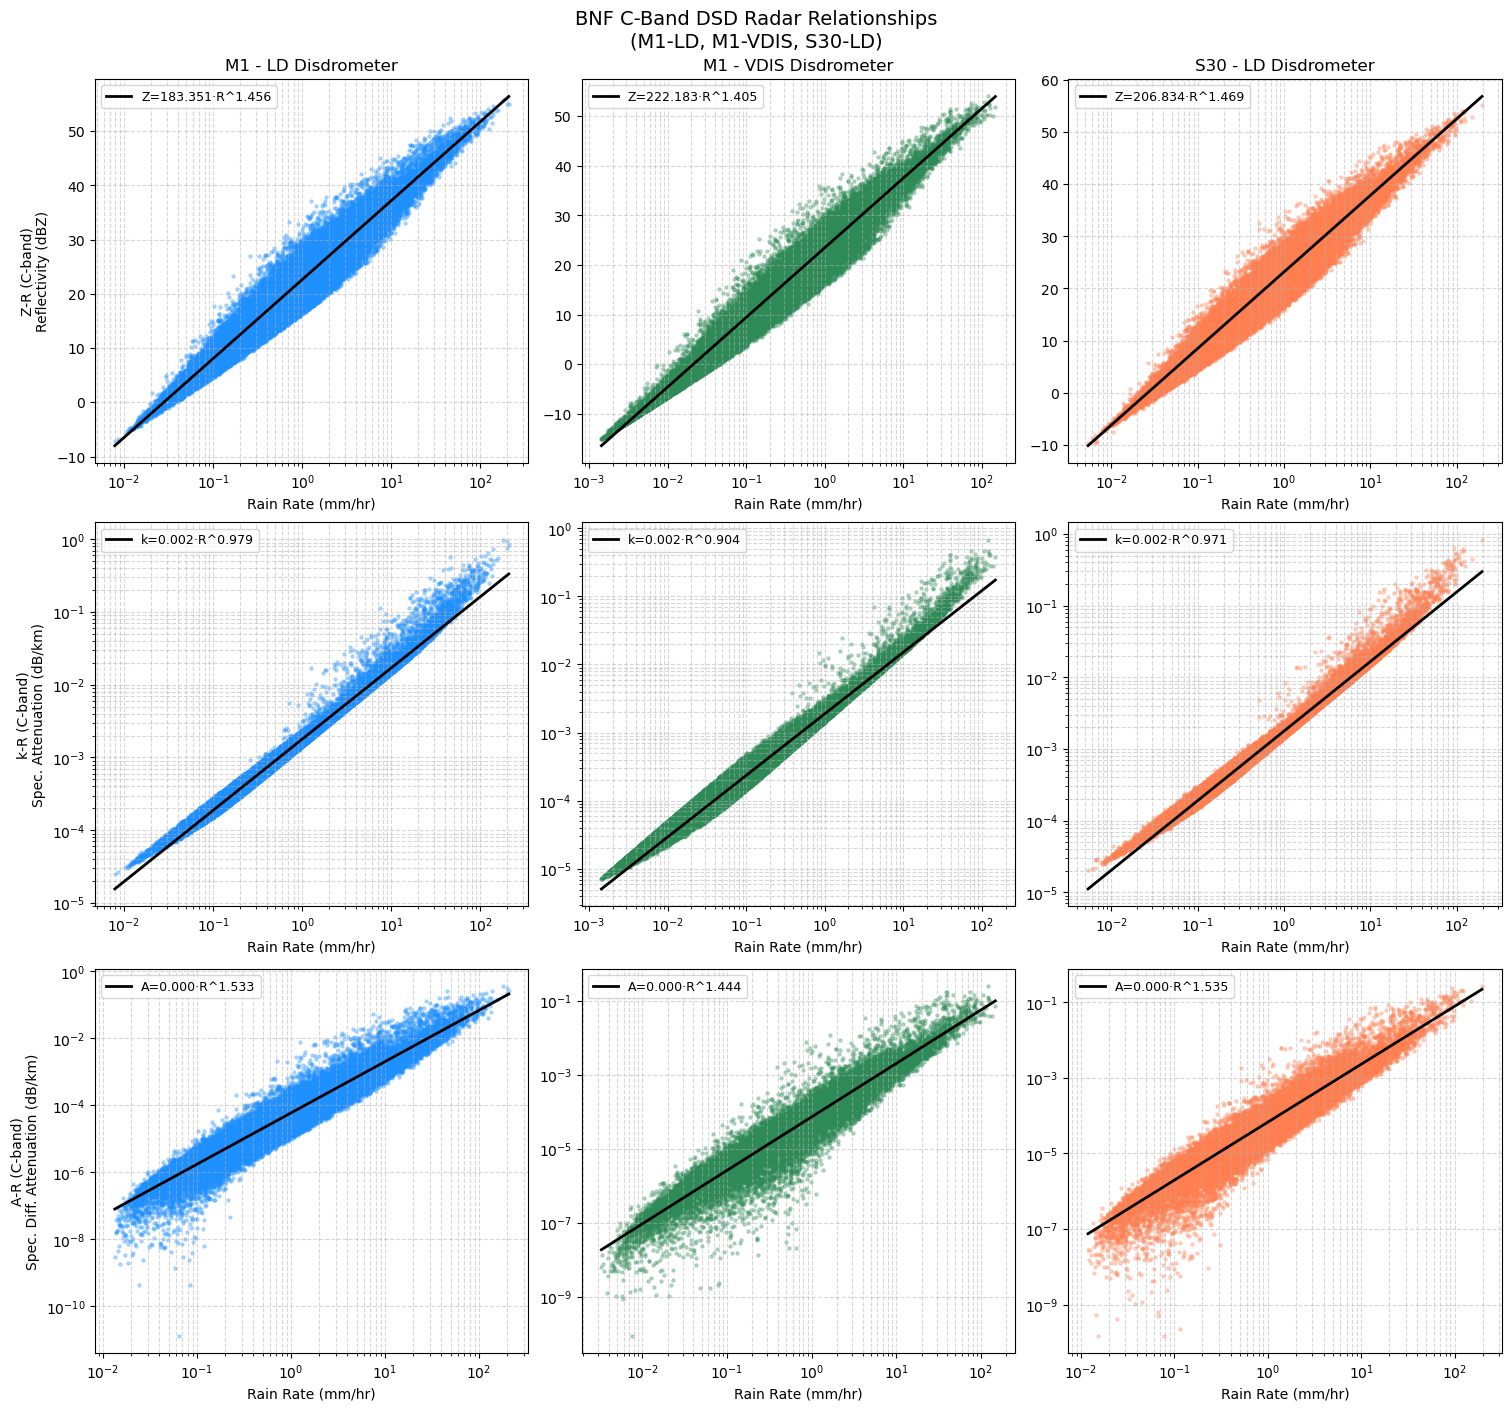

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(15, 14), constrained_layout=True)

colors       = ['dodgerblue', 'seagreen', 'coral']
display_info = {
    'Z-R': ('Z-R (C-band)',  'Reflectivity (dBZ)'),
    'k-R': ('k-R (C-band)',  'Spec. Attenuation (dB/km)'),
    'A-R': ('A-R (C-band)',  'Spec. Diff. Attenuation (dB/km)'),
}

# Build a lookup dict so the plot loop never re-calls fit_power_law
coeffs = {(r['Site'], r['Relationship']): (r['a'], r['b'])
          for _, r in df_results.iterrows()}

for col_idx, (site_name, ds) in enumerate(datasets):
    R_raw = ds[rain_var].values.astype(float)

    for row_idx, (rel, var, is_dbz) in enumerate(radar_vars):
        ax    = axes[row_idx, col_idx]
        y_raw = ds[var].values.astype(float)
        a, b  = coeffs[(site_name, rel)]
        sym   = rel.split('-')[0]
        row_label, ylabel = display_info[rel]

        # Mirror the validity filter used in fit_power_law
        y_check = 10 ** (y_raw / 10) if is_dbz else y_raw
        valid   = np.isfinite(R_raw) & np.isfinite(y_check) & (R_raw > 0) & (y_check > 0)
        R_v, y_v = R_raw[valid], y_raw[valid]   # keep original units for scatter

        R_fit = np.logspace(np.log10(R_v.min()), np.log10(R_v.max()), 100)
        y_fit = 10 * np.log10(a * R_fit ** b) if is_dbz else a * R_fit ** b

        ax.scatter(R_v, y_v, alpha=0.3, s=5, color=colors[col_idx])
        ax.plot(R_fit, y_fit, color='black', linewidth=2,
                label=f'{sym}={a:.3f}·R^{b:.3f}')
        ax.set_xscale('log')
        if not is_dbz:
            ax.set_yscale('log')
        ax.set_xlabel('Rain Rate (mm/hr)')
        ax.legend(fontsize=9)
        ax.grid(True, which='both', ls='--', alpha=0.5)

        if row_idx == 0:
            ax.set_title(site_name)
        if col_idx == 0:
            ax.set_ylabel(f'{row_label}\n{ylabel}')

plt.suptitle('BNF C-Band DSD Radar Relationships\n(M1-LD, M1-VDIS, S30-LD)', fontsize=14)
plt.show()

#### Combined Coefficients — All Instruments and Sites

Pool data from all three instruments and sites into a single array to derive best-estimate power-law coefficients for each relationship. Append to `df_results` for a complete comparison table.

In [16]:
R_all = np.concatenate([ds[rain_var].values.astype(float) for _, ds in datasets])

combined_records = []
for rel, var, is_dbz in radar_vars:
    y_all = np.concatenate([ds[var].values.astype(float) for _, ds in datasets])
    a, b, n = fit_power_law(R_all, y_all, is_dbz=is_dbz)
    combined_records.append({'Site': 'All Combined', 'Relationship': rel, 'a': a, 'b': b, 'N': n})

df_all = pd.concat([df_results, pd.DataFrame(combined_records)], ignore_index=True)
print(df_all.to_string(index=False))

                 Site Relationship          a        b      N
  M1 - LD Disdrometer          Z-R 183.351142 1.456210  37722
  M1 - LD Disdrometer          k-R   0.001790 0.979469  37722
  M1 - LD Disdrometer          A-R   0.000059 1.532736  37467
M1 - VDIS Disdrometer          Z-R 222.182835 1.404985  29103
M1 - VDIS Disdrometer          k-R   0.001889 0.904044  29103
M1 - VDIS Disdrometer          A-R   0.000073 1.443765  24973
 S30 - LD Disdrometer          Z-R 206.834247 1.468781  34755
 S30 - LD Disdrometer          k-R   0.001770 0.970649  34755
 S30 - LD Disdrometer          A-R   0.000067 1.535027  33944
         All Combined          Z-R 202.246395 1.426901 101580
         All Combined          k-R   0.001823 0.938924 101580
         All Combined          A-R   0.000066 1.497553  96384
